## PROJECT: Data curve fitting

In [1]:
# import all necessary modules
import numpy as np
import matplotlib.pyplot as plt

!pip install lmfit
import lmfit.models as models
from lmfit import Model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00


# Fit a Gaussian

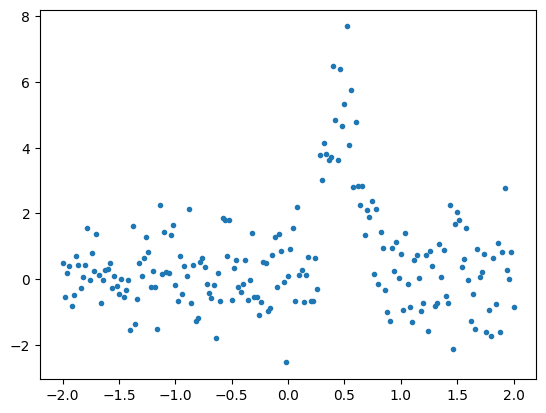

In [2]:
# Gaussian model
gausmodel = models.gaussian

# Gaussian parameters
x = np.linspace(-2,2,201)
a = 2   # amplitude
c = .5  # center
s = .15 # standard deviation (width)

# generate some data using the model
data = gausmodel(x,a,c,s) + np.random.randn(len(x))

# and plot
plt.plot(x,data,'.')
plt.show()

In [3]:
# fit the model to the data

gausfit = Model(gausmodel)
result = gausfit.fit(data,x=x)

# R2 fit
r2 = np.corrcoef(data,result.best_fit)[0,1]**2

# print model statistics
result

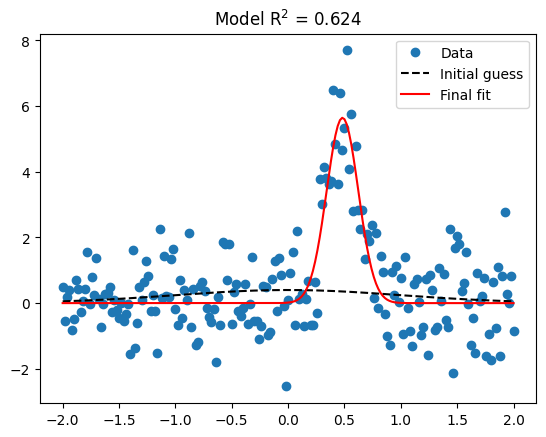

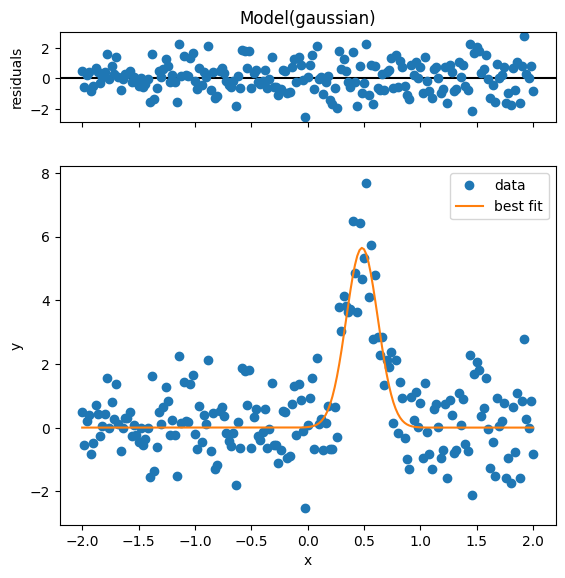

In [4]:
# some visualization
plt.plot(x,data,'o',label='Data')
plt.plot(x,result.init_fit,'k--', label='Initial guess')
plt.plot(x,result.best_fit,'r-', label='Final fit')
plt.legend()
plt.title('Model R$^2$ = %.3f'%r2)
plt.show()

print('\n\n\n\n')

# using built-in method
result.plot();


# Model an exponential decay

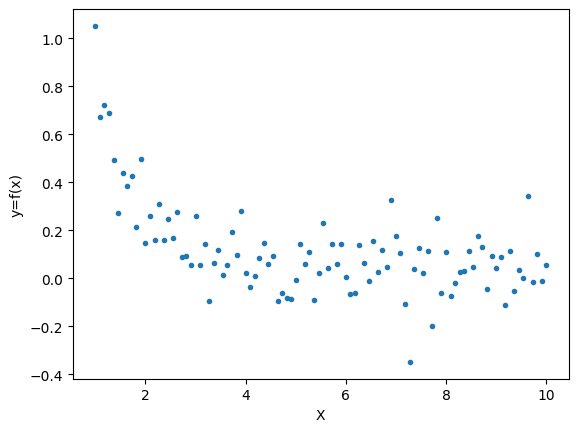

In [5]:
# x variable exponential decay
x = np.linspace(1,10,100)

# generate some data (not using the lmfit model)
data = 1/x**2 + np.random.normal(loc=0,scale=np.sqrt(.01),size=len(x))

# and plot
plt.plot(x,data,'.')
plt.xlabel('X')
plt.ylabel('y=f(x)')
plt.show()

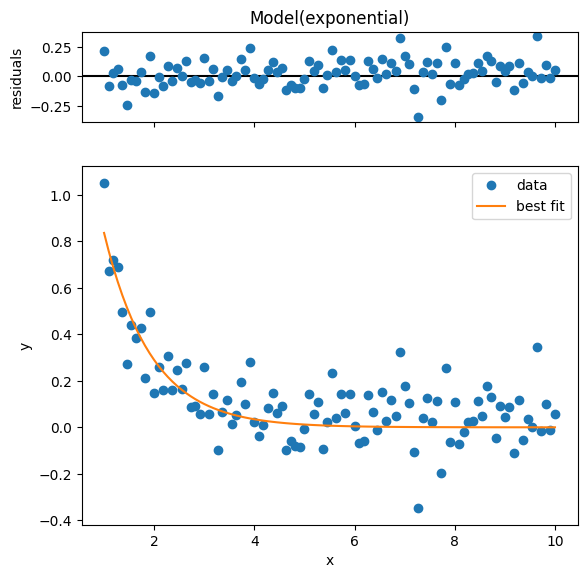

In [6]:
# fit model and show the results
expdecay_fit = Model(models.exponential)
result = expdecay_fit.fit(data,x=x)

result.plot();

# Use a user-defined function (sigmoid)

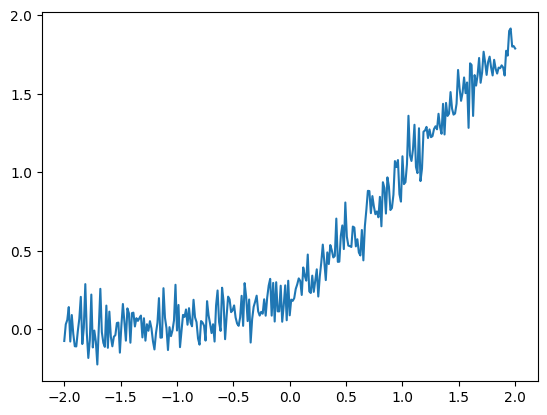

In [7]:
# create the data
x = np.linspace(-2,2,301)
data = 2 / (1+np.exp(-2*(x-1))) + np.random.randn(len(x))/10

plt.plot(x,data);

In [8]:
# let's make our own function for the sigmoid

def sigmoid(x,a=1,b=1,c=0):
  eterm = np.exp(-b*(x-c))
  return a / (1+eterm)


# then fit that model
sigmodel = Model(sigmoid)
result = sigmodel.fit(data,x=x)

# R2 fit
r2 = np.corrcoef(data,result.best_fit)[0,1]**2

# print model statistics
result


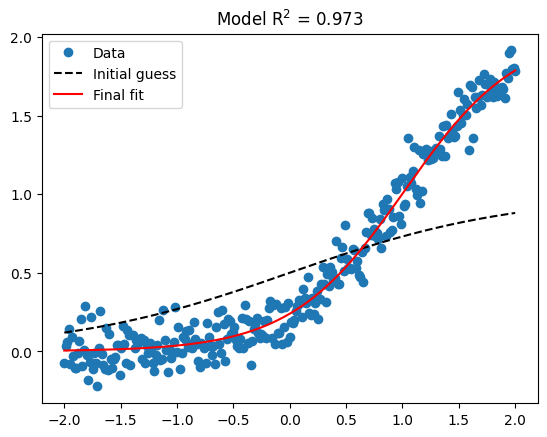

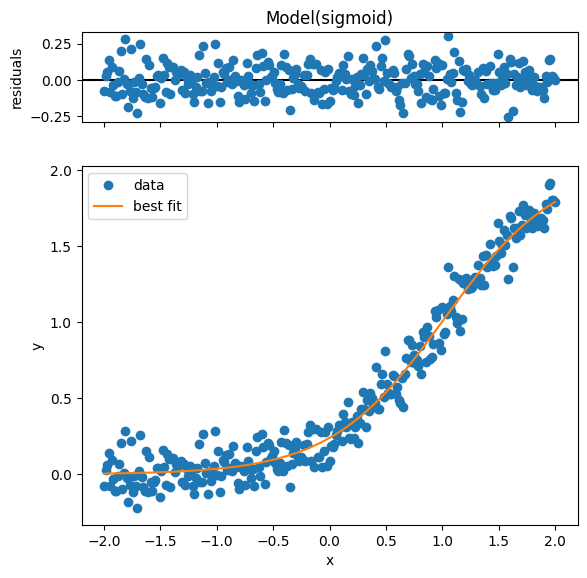

In [9]:
# some visualization
plt.plot(x,data,'o',label='Data')
plt.plot(x,result.init_fit,'k--', label='Initial guess')
plt.plot(x,result.best_fit,'r-', label='Final fit')
plt.legend()
plt.title('Model R$^2$ = %.3f'%r2)
plt.show()

print('\n\n\n\n')

# using built-in method
result.plot();

# Conjunctive model fitting

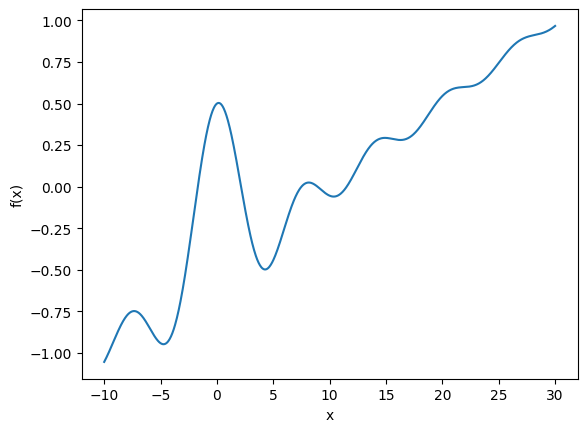

In [10]:
# create data
x = np.linspace(-10,30,1000)
data = np.sin(x)/x + np.linspace(-1,1,len(x))

plt.plot(x,data)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

In [11]:
# define the model
conj_model = Model(models.gaussian) + Model(models.linear)

# compute the model
gauslin = conj_model.fit(data,x=x)

# R2 fit
r2 = np.corrcoef(data,gauslin.best_fit)[0,1]**2

# print model statistics
gauslin

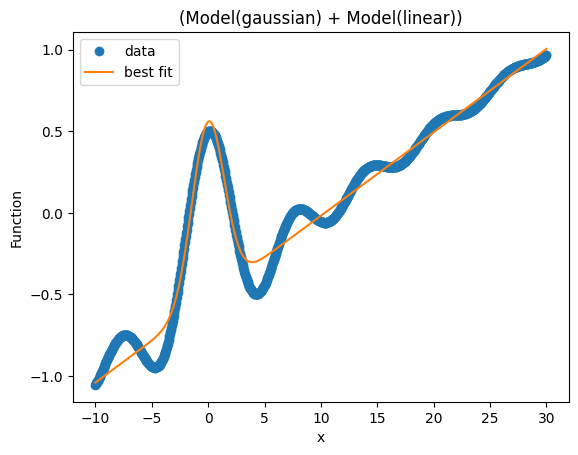

In [12]:
# using built-in method with extra options
gauslin.plot_fit(ylabel='Function',xlabel='x',show_init=False);


# Multivariate model fitting

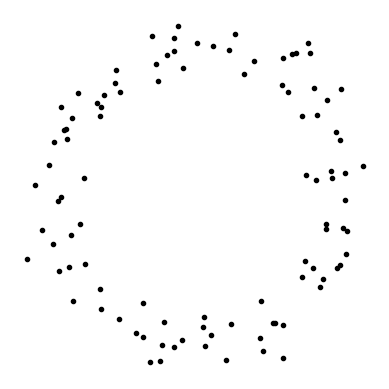

In [13]:
# create the circle data
n = 100

th = np.linspace(0,2*np.pi,n)
r = 3

# x and y values from cos and sine (and add a bit of noise)
x = r*np.cos(th) + np.random.normal(0,1/r,n) # note: np.random.normal has second input std. not var
y = r*np.sin(th) + np.random.normal(0,1/r,n)

plt.plot(x,y,'k.')
plt.gca().set_aspect(1./plt.gca().get_data_ratio())
plt.axis('off')
plt.show()

In [14]:
# confirmation!
print( np.var( np.random.normal(0,1/r,n*10) ) )
print( 1/(r**2) )

0.11916806090117285
0.1111111111111111


In [15]:
# the function to fit
def circlefit(th,r=1):
  x = r*np.cos(th)
  y = r*np.sin(th)
  return x,y


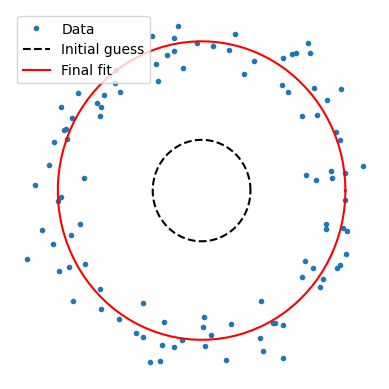

In [16]:
# define the model
circ_model = Model(circlefit)
result = circ_model.fit((x,y),th=th)

# visualize
plt.plot(x,y,'.',label='Data')
plt.plot(result.init_fit[0],result.init_fit[1],'k--', label='Initial guess')
plt.plot(result.best_fit[0],result.best_fit[1],'r-', label='Final fit')
plt.legend()
plt.gca().set_aspect(1./plt.gca().get_data_ratio())
plt.axis('off')
plt.show()

# Bonus: The eye of Sauron!

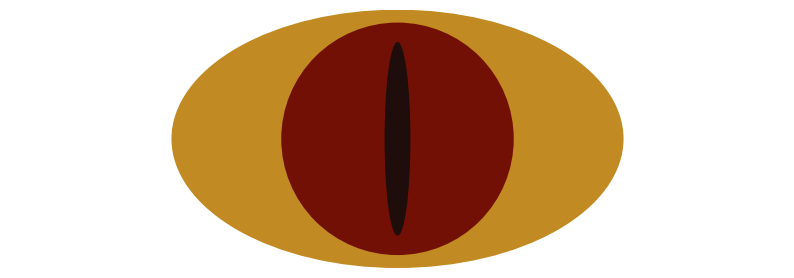

In [17]:
from matplotlib.patches import Ellipse

# the sclera
e1 = Ellipse((0,0),width=35, height=20)
e1.set_facecolor((194/255,138/255,35/255))

# the cornea
e2 = Ellipse((0,0),width=18, height=18)
e2.set_facecolor((115/255,16/255,5/255))

# the pupil
e3 = Ellipse((0,0),width=2, height=15)
e3.set_facecolor((30/255,13/255,10/255))


fig, ax = plt.subplots(subplot_kw={'aspect':'equal'},figsize=(10,10))
ax.add_artist(e1)
ax.add_artist(e2)
ax.add_artist(e3)

ax.set_xlim(-30,30)
ax.set_ylim(-10,10)
ax.set_axis_off()
plt.show()